In [1]:
import nest_asyncio

nest_asyncio.apply()

from dotenv import load_dotenv


assert load_dotenv("../.env", override=True), "failed to load .env"

In [2]:
!docker exec crystalvision-ollama-1 ollama pull $OLLAMA_CHAT_MODEL

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest 
pulling dde5aa3fc5ff... 100% ▕████████████████▏ 2.0 GB                         
pulling 966de95ca8a6... 100% ▕████████████████▏ 1.4 KB                         
pulling fcc5a6bec9da... 100% ▕████████████████▏ 7.7 KB                         
pulling a70ff7e570d9... 100% ▕████████████████▏ 6.0 KB                         
pulling 56bb8bd477a5... 100% ▕████████████████▏   96 B                         
pulling 34bb5ab01051... 100% ▕████████████████▏  561 B                         
verifying sha256 digest 
writing manifest 
success 


In [3]:
import os
from langchain_ollama import OllamaEmbeddings
from langchain_ollama import ChatOllama

llm = ChatOllama(model=os.getenv("OLLAMA_CHAT_MODEL"), temperature=0)
embedding = OllamaEmbeddings(model=os.getenv("OLLAMA_EMBED_MODEL"))

In [4]:
from typing import Optional, Type
from IPython.display import display, Image as IPImage
from PIL import Image as PILImage
from pathlib import Path
from pydantic import BaseModel, Field
from langchain.callbacks.manager import (
    AsyncCallbackManagerForToolRun,
    CallbackManagerForToolRun,
)
from langchain.tools import BaseTool


# Define the input schema for the tool
class ImageRetrievalInput(BaseModel):
    card_code: str = Field(description="the card code often in a ##-###[CRHLS] format")


# Create the tool
class FFTCGImageTool(BaseTool):
    name: str = "FFTCG Card Image Finder"
    description: str = (
        "Useful for finding and sending images of FFTCG cards based on card names"
    )
    args_schema: Type[BaseModel] = ImageRetrievalInput
    return_direct: bool = True

    def _run(
        self, card_code: str, run_manager: Optional[CallbackManagerForToolRun] = None
    ) -> str:
        """Find the card image and send it via Discord."""
        image_path = self.get_image_path(card_code)  # Find the image path for the card

        if image_path:
            # Send the image via Discord
            # self.send_image_via_discord(image_path)
            self.display_image(image_path)
            return f"Image of {card_code} sent."
        else:
            return f"No image found for card: {card_code}"

    def display_image(self, image_path):
        """Display the image in the notebook."""
        img = PILImage.open(image_path)
        display(IPImage(image_path))
        return img

    def get_image_path(self, card_name):
        """Find the image for the card based on the card name."""
        image_path = (".." / Path("data") / "img" / f"{card_name}_eg.jpg").resolve()
        print(image_path)
        return image_path if image_path.exists() else None

    async def _arun(
        self,
        card_name: str,
        run_manager: Optional[AsyncCallbackManagerForToolRun] = None,
    ) -> str:
        """Find the card image asynchronously and send it via Discord."""
        image_path = self.get_image_path(card_name)  # Find the image path for the card

        if image_path:
            return f"Image of {card_name} sent."

        return f"No image found for card: {card_name}"

In [5]:
from langchain.agents import create_tool_calling_agent
from langchain import hub

# Get the prompt to use - you can modify this!
prompt = hub.pull("hwchase17/openai-functions-agent")

from langchain.prompts import PromptTemplate

# Create a prompt template with placeholders for input variables
prompt_template = PromptTemplate(
    input_variables=["query", "context"],
    template="""
    You are an expert on Final Fantasy Trading Card Game (FFTCG). Answer the question with respect to FFTCG only. Use the following pieces of retrieved context to answer the question.
    
    {context}

    Question: {question}

    Answer:
    """,
)

tools = [FFTCGImageTool()]

agent = create_tool_calling_agent(llm, tools, prompt)

from langchain.agents import AgentExecutor

agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

/home/acbaraka/.cache/pypoetry/virtualenvs/crystalvision-4sHt3Jis-py3.11/lib/python3.11/site-packages/langsmith/client.py:261: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(




> Entering new AgentExecutor chain...

Invoking: `FFTCG Card Image Finder` with `{'card_code': '1-001H'}`


/mnt/d/CrystalVision/data/img/1-001H_eg.jpg


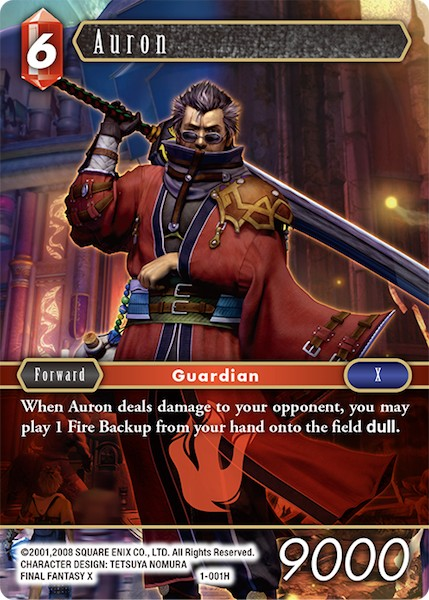

Image of 1-001H sent.


> Finished chain.


{'input': 'Show me an image of 1-001H', 'output': 'Image of 1-001H sent.'}

In [6]:
agent_executor.invoke({"input": "Show me an image of 1-001H"})

In [7]:
agent_executor.invoke({"input": "Show me an image of Auron"})



> Entering new AgentExecutor chain...

Invoking: `FFTCG Card Image Finder` with `{'card_code': 'AURON'}`


/mnt/d/CrystalVision/data/img/AURON_eg.jpg
No image found for card: AURON


> Finished chain.


{'input': 'Show me an image of Auron',
 'output': 'No image found for card: AURON'}

In [8]:
agent_executor.invoke({"input": "Show me Zenos"})



> Entering new AgentExecutor chain...

Invoking: `FFTCG Card Image Finder` with `{'card_code': 'Zenos'}`


/mnt/d/CrystalVision/data/img/Zenos_eg.jpg
No image found for card: Zenos


> Finished chain.


{'input': 'Show me Zenos', 'output': 'No image found for card: Zenos'}